# ConvNeXt-Large Training

This notebook provides a publication-ready training workflow for the ConvNeXt-Large second-stage classifier used in the DeathScope pyroptosis extension.

The notebook is intentionally limited to the steps that belong in a reproducible training artifact:
- dataset discovery and deterministic train/validation splitting
- preprocessing and augmentation
- ConvNeXt-Large fine-tuning
- checkpointing and training history export
- final evaluation and qualitative validation preview

Accepted input layouts:
- flat class folders: `SOURCE_DATA_ROOT/class_a/*.png`
- grouped class folders: `SOURCE_DATA_ROOT/group_name/class_a/*.png`
- pre-split ImageFolder layout: `SOURCE_DATA_ROOT/train/class_a/*.png` and `SOURCE_DATA_ROOT/val/class_a/*.png`

The current curated training dataset uses the grouped layout, for example `training/ConvNeXt/source_data/WT_TC/apoptosis/*.png` and `training/ConvNeXt/source_data/WT_LN/pyroptosis/*.png`.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from hashlib import sha1
from pathlib import Path
import json
import math
import os
import random
import shutil
import sys
import time

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from timm import create_model


def find_repo_root() -> Path:
    candidate = Path.cwd().resolve()
    while candidate != candidate.parent and not (candidate / "pyproject.toml").exists():
        candidate = candidate.parent
    if not (candidate / "pyproject.toml").exists():
        raise FileNotFoundError("Could not locate the repository root containing pyproject.toml.")
    return candidate


repo_root = find_repo_root()
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print(f"Repository root: {repo_root}")
print(f"Torch version:    {torch.__version__}")


/media/capp/TMP2/DeathScope/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository root: /media/capp/TMP2/DeathScope
Torch version:    2.10.0+cu128


## Configuration

The defaults below are conservative and notebook-friendly. For a full training run, update the dataset path and increase `EPOCHS` and `BATCH_SIZE` to match your hardware.


In [9]:
SOURCE_DATA_ROOT = repo_root / "training/ConvNeXt/source_data"
RUN_DIR = repo_root / "training/ConvNeXt"
SPLIT_ROOT = RUN_DIR / "ImageFolder"

IMAGE_PATTERNS = ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff")
VAL_RATIO = 0.2
COPY_FILES = True          # True copies files; False creates symlinks
SEED = 42
REUSE_EXISTING_SPLIT = True

ARCHITECTURE = "convnext_large.fb_in22k_ft_in1k"
IMAGE_SIZE = 48
BATCH_SIZE = 16
EPOCHS = 80
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-2
CONTINUE_TRAINING = False
RESUME_CHECKPOINT = RUN_DIR / "checkpoint_last.pth"
LABEL_SMOOTHING = 0.05
GRAD_CLIP_NORM = 1.0
NUM_WORKERS = 4
USE_PRETRAINED = True
AMP_ENABLED = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRAIN_MEAN = (0.5, 0.5, 0.5)
TRAIN_STD = (0.25, 0.25, 0.25)

RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"Source data root: {SOURCE_DATA_ROOT}")
print(f"Run directory:    {RUN_DIR}")
print(f"Device:           {DEVICE}")


Source data root: /media/capp/TMP2/DeathScope/training/ConvNeXt/source_data
Run directory:    /media/capp/TMP2/DeathScope/training/ConvNeXt
Device:           cuda


## Dataset Preparation

This section accepts any of the following:
- a flat class-folder dataset under `SOURCE_DATA_ROOT`
- a grouped dataset under `SOURCE_DATA_ROOT/group_name/class_name`
- an existing ImageFolder-style split with `train/` and `val/` under `SOURCE_DATA_ROOT`

When a split does not already exist, the notebook creates one deterministically under `RUN_DIR/ImageFolder`.


In [5]:
IMAGE_SUFFIXES = {pattern.replace("*", "").lower() for pattern in IMAGE_PATTERNS}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES


def list_images(directory: Path) -> list[Path]:
    return sorted([path for path in directory.iterdir() if is_image_file(path)])


def dataset_has_explicit_split(root: Path) -> bool:
    return (root / "train").is_dir() and (root / "val").is_dir()


def class_dirs_from_split(split_dir: Path) -> list[Path]:
    return sorted([path for path in split_dir.iterdir() if path.is_dir()])


def direct_class_dirs(root: Path) -> list[Path]:
    return sorted([path for path in root.iterdir() if path.is_dir() and list_images(path)])


def grouped_class_dir_map(root: Path) -> dict[str, list[Path]]:
    grouped: dict[str, list[Path]] = {}
    for dataset_dir in sorted([path for path in root.iterdir() if path.is_dir()]):
        child_class_dirs = [path for path in dataset_dir.iterdir() if path.is_dir() and list_images(path)]
        for class_dir in sorted(child_class_dirs):
            grouped.setdefault(class_dir.name, []).append(class_dir)
    return grouped


def collect_source_class_dirs(root: Path) -> tuple[dict[str, list[Path]], str]:
    flat_dirs = direct_class_dirs(root)
    if flat_dirs:
        return {path.name: [path] for path in flat_dirs}, "flat"

    grouped_dirs = grouped_class_dir_map(root)
    if grouped_dirs:
        return grouped_dirs, "grouped"

    raise ValueError(
        f"Could not infer a supported dataset layout under {root}. Expected flat class folders, grouped class folders, or a pre-split ImageFolder layout."
    )


def validate_binary_classes(class_names: list[str]) -> None:
    if len(class_names) != 2:
        raise ValueError(
            f"This notebook is intended for the binary ConvNeXt classifier and expects exactly 2 classes, found {class_names}."
        )


def unique_name(src_path: Path, label: str) -> str:
    digest = sha1(str(src_path.resolve()).encode("utf-8")).hexdigest()[:8]
    return f"{src_path.stem}_{label}_{digest}{src_path.suffix.lower()}"


def materialize_split(source_root: Path, split_root: Path, val_ratio: float, copy_files: bool, seed: int) -> tuple[Path, list[str], str]:
    class_dir_map, source_layout = collect_source_class_dirs(source_root)
    class_names = sorted(class_dir_map)
    validate_binary_classes(class_names)

    if split_root.exists() and REUSE_EXISTING_SPLIT and dataset_has_explicit_split(split_root):
        return split_root, class_names, source_layout

    split_root.mkdir(parents=True, exist_ok=True)
    rng = random.Random(seed)

    for class_name, class_dirs in class_dir_map.items():
        images = []
        for class_dir in class_dirs:
            images.extend(list_images(class_dir))
        if len(images) < 2:
            raise ValueError(f"Need at least 2 images for class '{class_name}' to create train/val splits.")

        shuffled = images[:]
        rng.shuffle(shuffled)
        val_count = max(1, int(round(len(shuffled) * val_ratio)))
        val_count = min(val_count, len(shuffled) - 1)
        val_files = shuffled[:val_count]
        train_files = shuffled[val_count:]

        for split_name, split_files in (("train", train_files), ("val", val_files)):
            out_dir = split_root / split_name / class_name
            out_dir.mkdir(parents=True, exist_ok=True)
            for src in split_files:
                dst = out_dir / unique_name(src, class_name)
                if dst.exists():
                    continue
                if copy_files:
                    shutil.copy2(src, dst)
                else:
                    os.symlink(src.resolve(), dst)

    return split_root, class_names, source_layout


def resolve_dataset_root(source_root: Path, split_root: Path) -> tuple[Path, list[str], str]:
    if not source_root.exists():
        raise FileNotFoundError(f"Dataset root not found: {source_root}")

    if dataset_has_explicit_split(source_root):
        class_names = [path.name for path in class_dirs_from_split(source_root / "train")]
        validate_binary_classes(class_names)
        return source_root, sorted(class_names), "explicit_split"

    return materialize_split(source_root, split_root, VAL_RATIO, COPY_FILES, SEED)


def summarize_source_root(source_root: Path, source_layout: str) -> pd.DataFrame:
    records = []
    if source_layout == "grouped":
        for dataset_dir in sorted([path for path in source_root.iterdir() if path.is_dir()]):
            for class_dir in sorted([path for path in dataset_dir.iterdir() if path.is_dir() and list_images(path)]):
                records.append({
                    "source_group": dataset_dir.name,
                    "class_name": class_dir.name,
                    "count": len(list_images(class_dir)),
                })
    elif source_layout == "flat":
        for class_dir in direct_class_dirs(source_root):
            records.append({
                "source_group": source_root.name,
                "class_name": class_dir.name,
                "count": len(list_images(class_dir)),
            })
    return pd.DataFrame(records)


def summarize_split(dataset_root: Path) -> pd.DataFrame:
    records = []
    for split_name in ("train", "val"):
        split_dir = dataset_root / split_name
        for class_dir in class_dirs_from_split(split_dir):
            records.append({
                "split": split_name,
                "class_name": class_dir.name,
                "count": len(list_images(class_dir)),
            })
    return pd.DataFrame(records)


dataset_root, class_names, source_layout = resolve_dataset_root(SOURCE_DATA_ROOT, SPLIT_ROOT)
class_to_idx = {name: index for index, name in enumerate(class_names)}
idx_to_class = {index: name for name, index in class_to_idx.items()}

with (RUN_DIR / "classes.json").open("w", encoding="utf-8") as file:
    json.dump({"class_to_idx": class_to_idx, "idx_to_class": idx_to_class}, file, indent=2)

source_summary = summarize_source_root(SOURCE_DATA_ROOT, source_layout)
if not source_summary.empty:
    display(source_summary)

split_summary = summarize_split(dataset_root)
display(split_summary)
print(f"Using dataset root: {dataset_root}")
print(f"Detected source layout: {source_layout}")
print(f"Class mapping: {idx_to_class}")


,source_group,class_name,count
0,LN,pyroptosis,2996
1,TC,apoptosis,2059


,split,class_name,count
0,train,apoptosis,1647
1,train,pyroptosis,2397
2,val,apoptosis,412
3,val,pyroptosis,599


Using dataset root: /media/capp/TMP2/DeathScope/training/ConvNeXt/ImageFolder
Detected source layout: grouped
Class mapping: {0: 'apoptosis', 1: 'pyroptosis'}


## Transforms And Dataloaders

The classifier consumes three-channel tensors so grayscale crops are converted to RGB before augmentation. Validation preprocessing is aligned with the normalization used by the packaged `deathscope.pyro_classifier` predictor.


In [10]:
def build_transforms(image_size: int) -> tuple[A.Compose, A.Compose]:
    train_transform = A.Compose(
        [
            A.RandomResizedCrop(image_size, image_size, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.GaussNoise(var_limit=(5.0, 30.0), p=0.25),
            A.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD),
            ToTensorV2(),
        ]
    )
    val_transform = A.Compose(
        [
            A.LongestMaxSize(max_size=image_size),
            A.PadIfNeeded(
                min_height=image_size,
                min_width=image_size,
                border_mode=cv2.BORDER_REFLECT_101,
            ),
            A.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD),
            ToTensorV2(),
        ]
    )
    return train_transform, val_transform


def load_rgb_image(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Failed to read image: {image_path}")
    return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)


class ConvNeXtImageFolderDataset(Dataset):
    def __init__(self, split_dir: Path, class_to_idx: dict[str, int], transform: A.Compose):
        self.split_dir = Path(split_dir)
        self.class_to_idx = dict(class_to_idx)
        self.transform = transform
        self.samples = self._collect_samples()

    def _collect_samples(self) -> list[tuple[Path, int]]:
        samples = []
        for class_name, class_index in self.class_to_idx.items():
            class_dir = self.split_dir / class_name
            if not class_dir.is_dir():
                raise FileNotFoundError(f"Missing class directory: {class_dir}")
            for image_path in list_images(class_dir):
                samples.append((image_path, class_index))
        if not samples:
            raise ValueError(f"No samples found under {self.split_dir}")
        return samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        image_path, target = self.samples[index]
        image = load_rgb_image(image_path)
        tensor = self.transform(image=image)["image"].float()
        return tensor, target, str(image_path)


train_transform, val_transform = build_transforms(IMAGE_SIZE)
train_ds = ConvNeXtImageFolderDataset(dataset_root / "train", class_to_idx, train_transform)
val_ds = ConvNeXtImageFolderDataset(dataset_root / "val", class_to_idx, val_transform)

pin_memory = DEVICE.startswith("cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
)

print(f"Training samples:   {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")


Training samples:   4044
Validation samples: 1011


## Model And Training Utilities

The training loop saves:
- `model_best.pth`
- `checkpoint_last.pth`
- `classes.json`
- `history.json`
- `history.csv`
- `final_metrics.json`

These outputs are written to `RUN_DIR` and are intended to be consumed directly by the accompanying prediction and plotting notebooks.


In [11]:
@dataclass
class EpochMetrics:
    loss: float
    acc: float
    f1: float
    auc: float


def binary_auc_score(targets: np.ndarray, positive_scores: np.ndarray) -> float:
    targets = np.asarray(targets, dtype=np.int64)
    positive_scores = np.asarray(positive_scores, dtype=np.float64)
    positives = int((targets == 1).sum())
    negatives = int((targets == 0).sum())
    if positives == 0 or negatives == 0:
        return float("nan")

    order = np.argsort(positive_scores, kind="mergesort")
    sorted_scores = positive_scores[order]
    ranks = np.zeros(len(sorted_scores), dtype=np.float64)

    start = 0
    while start < len(sorted_scores):
        stop = start + 1
        while stop < len(sorted_scores) and sorted_scores[stop] == sorted_scores[start]:
            stop += 1
        average_rank = (start + stop - 1) / 2.0 + 1.0
        ranks[order[start:stop]] = average_rank
        start = stop

    positive_ranks = ranks[targets == 1].sum()
    return float((positive_ranks - positives * (positives + 1) / 2.0) / (positives * negatives))


def confusion_counts(targets: np.ndarray, preds: np.ndarray) -> tuple[int, int, int, int]:
    targets = np.asarray(targets, dtype=np.int64)
    preds = np.asarray(preds, dtype=np.int64)
    tp = int(((targets == 1) & (preds == 1)).sum())
    tn = int(((targets == 0) & (preds == 0)).sum())
    fp = int(((targets == 0) & (preds == 1)).sum())
    fn = int(((targets == 1) & (preds == 0)).sum())
    return tp, tn, fp, fn


def compute_epoch_metrics(targets: list[int], preds: list[int], probs: list[float], loss_sum: float, sample_count: int) -> EpochMetrics:
    targets_np = np.asarray(targets, dtype=np.int64)
    preds_np = np.asarray(preds, dtype=np.int64)
    probs_np = np.asarray(probs, dtype=np.float64)
    accuracy = float((targets_np == preds_np).mean()) if len(targets_np) else float("nan")
    tp, tn, fp, fn = confusion_counts(targets_np, preds_np)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    auc = binary_auc_score(targets_np, probs_np)
    return EpochMetrics(
        loss=float(loss_sum / max(sample_count, 1)),
        acc=accuracy,
        f1=float(f1),
        auc=float(auc),
    )


def train_one_epoch(model, loader, optimizer, criterion, scaler, device, amp_enabled, grad_clip_norm):
    model.train()
    loss_sum = 0.0
    sample_count = 0
    targets_all, preds_all, probs_all = [], [], []

    progress = tqdm(loader, desc="train", leave=False)
    for images, targets, _paths in progress:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=amp_enabled and device.type == "cuda"):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        probabilities = torch.softmax(logits.detach(), dim=1)[:, 1]
        predictions = torch.argmax(logits.detach(), dim=1)

        batch_size = targets.size(0)
        loss_sum += float(loss.item()) * batch_size
        sample_count += batch_size
        targets_all.extend(targets.detach().cpu().tolist())
        preds_all.extend(predictions.cpu().tolist())
        probs_all.extend(probabilities.cpu().tolist())

        progress.set_postfix(loss=f"{loss.item():.4f}")

    return compute_epoch_metrics(targets_all, preds_all, probs_all, loss_sum, sample_count)


def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum = 0.0
    sample_count = 0
    targets_all, preds_all, probs_all, paths_all = [], [], [], []

    with torch.inference_mode():
        progress = tqdm(loader, desc="val", leave=False)
        for images, targets, paths in progress:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, targets)

            probabilities = torch.softmax(logits, dim=1)[:, 1]
            predictions = torch.argmax(logits, dim=1)

            batch_size = targets.size(0)
            loss_sum += float(loss.item()) * batch_size
            sample_count += batch_size
            targets_all.extend(targets.cpu().tolist())
            preds_all.extend(predictions.cpu().tolist())
            probs_all.extend(probabilities.cpu().tolist())
            paths_all.extend(paths)

    metrics = compute_epoch_metrics(targets_all, preds_all, probs_all, loss_sum, sample_count)
    return metrics, np.asarray(targets_all), np.asarray(preds_all), np.asarray(probs_all), paths_all


def build_model(architecture: str, num_classes: int, pretrained: bool) -> nn.Module:
    model = create_model(architecture, pretrained=pretrained, num_classes=num_classes)
    return model


def save_checkpoint(path: Path, model: nn.Module, optimizer, scheduler, epoch: int, metrics: dict, config: dict):
    payload = {
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict() if scheduler is not None else None,
        "metrics": metrics,
        "config": config,
    }
    torch.save(payload, path)


def load_checkpoint(path: Path, device: torch.device):
    if not path.is_file():
        raise FileNotFoundError(f"Checkpoint not found: {path}")
    return torch.load(path, map_location=device)


def is_better(candidate: dict, best: dict | None) -> bool:
    if best is None:
        return True
    candidate_key = (
        float("-inf") if math.isnan(candidate["val_auc"]) else candidate["val_auc"],
        candidate["val_f1"],
        candidate["val_acc"],
        -candidate["val_loss"],
    )
    best_key = (
        float("-inf") if math.isnan(best["val_auc"]) else best["val_auc"],
        best["val_f1"],
        best["val_acc"],
        -best["val_loss"],
    )
    return candidate_key > best_key


## Train

This cell performs the full fine-tuning run and writes all training artifacts to `RUN_DIR`.


In [12]:
device = torch.device(DEVICE)
model = build_model(ARCHITECTURE, num_classes=len(class_names), pretrained=USE_PRETRAINED).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler(enabled=AMP_ENABLED and device.type == "cuda")

config_payload = {
    "source_data_root": str(SOURCE_DATA_ROOT),
    "dataset_root": str(dataset_root),
    "run_dir": str(RUN_DIR),
    "class_to_idx": class_to_idx,
    "architecture": ARCHITECTURE,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "grad_clip_norm": GRAD_CLIP_NORM,
    "seed": SEED,
    "device": DEVICE,
}
with (RUN_DIR / "config.json").open("w", encoding="utf-8") as file:
    json.dump(config_payload, file, indent=2)

history = []
best_record = None
start_epoch = 1

if CONTINUE_TRAINING:
    checkpoint_payload = load_checkpoint(RESUME_CHECKPOINT, device)
    model.load_state_dict(checkpoint_payload["model"])
    optimizer.load_state_dict(checkpoint_payload["optimizer"])
    if scheduler is not None and checkpoint_payload.get("scheduler") is not None:
        scheduler.load_state_dict(checkpoint_payload["scheduler"])
    start_epoch = int(checkpoint_payload["epoch"]) + 1
    history_path = RUN_DIR / "history.json"
    if history_path.is_file():
        with history_path.open("r", encoding="utf-8") as file:
            history = json.load(file)
    for record in history:
        best_record = dict(record) if is_better(record, best_record) else best_record
    print(f"Resuming training from epoch {start_epoch} using {RESUME_CHECKPOINT}")

if start_epoch > EPOCHS:
    print(f"Checkpoint epoch {start_epoch - 1} already reaches or exceeds EPOCHS={EPOCHS}; skipping train loop.")

start_time = time.time()
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = time.time()
    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=device,
        amp_enabled=AMP_ENABLED,
        grad_clip_norm=GRAD_CLIP_NORM,
    )
    val_metrics, val_targets, val_preds, val_probs, val_paths = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )
    scheduler.step()

    record = {
        "epoch": epoch,
        "train_loss": train_metrics.loss,
        "train_acc": train_metrics.acc,
        "train_f1": train_metrics.f1,
        "val_loss": val_metrics.loss,
        "val_acc": val_metrics.acc,
        "val_f1": val_metrics.f1,
        "val_auc": val_metrics.auc,
        "lr": float(optimizer.param_groups[0]["lr"]),
        "seconds": float(time.time() - epoch_start),
    }
    history.append(record)

    save_checkpoint(
        RUN_DIR / "checkpoint_last.pth",
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        epoch=epoch,
        metrics=record,
        config=config_payload,
    )

    if is_better(record, best_record):
        best_record = dict(record)
        save_checkpoint(
            RUN_DIR / "model_best.pth",
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            metrics=record,
            config=config_payload,
        )
    
    with (RUN_DIR / "history.json").open("w", encoding="utf-8") as file:
        json.dump(history, file, indent=2)
    pd.DataFrame(history).to_csv(RUN_DIR / "history.csv", index=False)

    print(
        f"Epoch {epoch:03d}/{EPOCHS:03d} | "
        f"train_loss={record['train_loss']:.4f} train_acc={record['train_acc']:.4f} train_f1={record['train_f1']:.4f} | "
        f"val_loss={record['val_loss']:.4f} val_acc={record['val_acc']:.4f} val_f1={record['val_f1']:.4f} val_auc={record['val_auc']:.4f}"
    )

training_minutes = (time.time() - start_time) / 60.0
print(f"Training finished in {training_minutes:.2f} minutes")


/tmp/ipykernel_4122168/1894178647.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=AMP_ENABLED and device.type == "cuda")
train:   0%|          | 0/253 [00:00<?, ?it/s]/tmp/ipykernel_4122168/883263285.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled and device.type == "cuda"):


Epoch 001/080 | train_loss=0.5085 train_acc=0.7928 train_f1=0.8275 | val_loss=0.5049 val_acc=0.8071 val_f1=0.8576 val_auc=0.9267


Epoch 002/080 | train_loss=0.4028 train_acc=0.8608 train_f1=0.8821 | val_loss=0.4165 val_acc=0.8556 val_f1=0.8859 val_auc=0.9243


Epoch 003/080 | train_loss=0.3360 train_acc=0.8909 train_f1=0.9080 | val_loss=0.3352 val_acc=0.8892 val_f1=0.9077 val_auc=0.9552


Epoch 004/080 | train_loss=0.3218 train_acc=0.9003 train_f1=0.9156 | val_loss=0.3122 val_acc=0.9139 val_f1=0.9279 val_auc=0.9637


...

Epoch 076/080 | train_loss=0.1178 train_acc=0.9998 train_f1=0.9998 | val_loss=0.3628 val_acc=0.9179 val_f1=0.9322 val_auc=0.9704


Epoch 077/080 | train_loss=0.1190 train_acc=0.9993 train_f1=0.9994 | val_loss=0.3616 val_acc=0.9169 val_f1=0.9314 val_auc=0.9711


Epoch 078/080 | train_loss=0.1202 train_acc=0.9988 train_f1=0.9990 | val_loss=0.3597 val_acc=0.9169 val_f1=0.9310 val_auc=0.9717


Epoch 079/080 | train_loss=0.1177 train_acc=0.9998 train_f1=0.9998 | val_loss=0.3603 val_acc=0.9169 val_f1=0.9310 val_auc=0.9717


Epoch 080/080 | train_loss=0.1175 train_acc=0.9995 train_f1=0.9996 | val_loss=0.3603 val_acc=0.9169 val_f1=0.9310 val_auc=0.9717
Training finished in 62.64 minutes


## Final Evaluation

The next cell summarizes the best validation checkpoint, saves `final_metrics.json`, and renders quick publication-oriented sanity checks.


,best_epoch,val_loss,val_acc,val_f1,val_auc
0,39,0.330636,0.925816,0.938575,0.977373


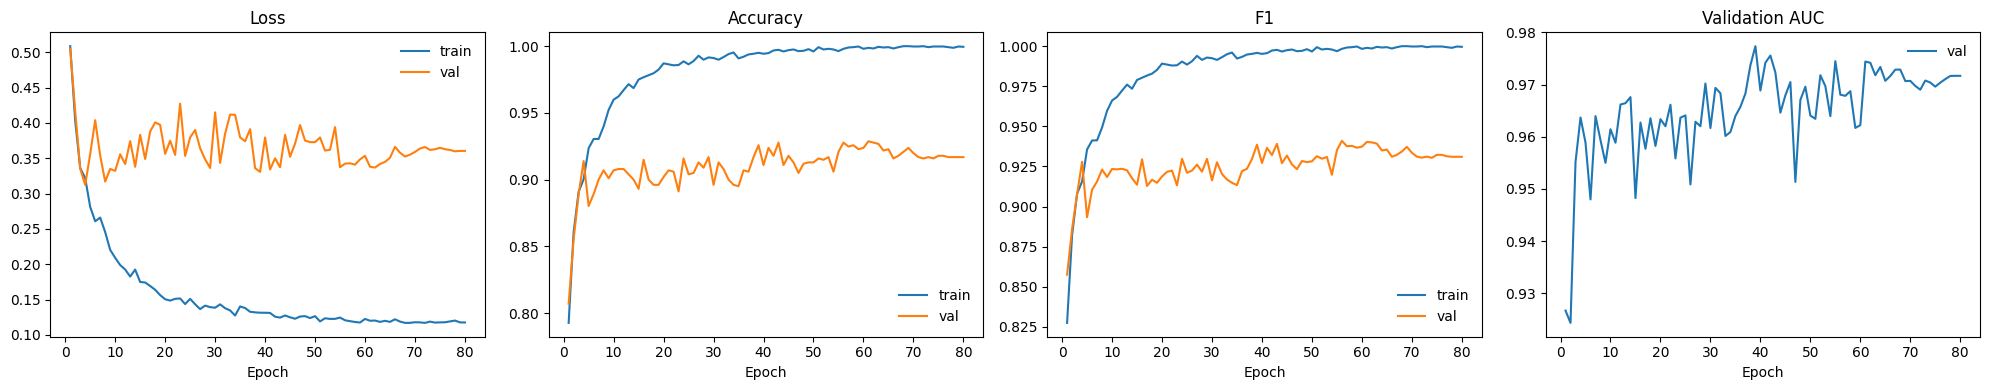

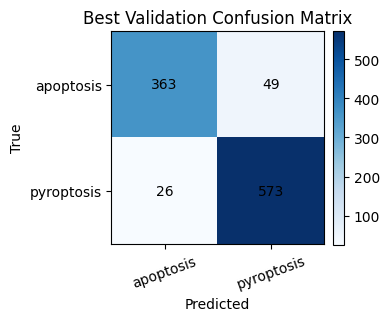

,path,target,pred,prob_class_1,correct
302,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.975655,False
266,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.975493,False
8,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.975376,False
82,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.974797,False
329,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.974782,False
137,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.974755,False
346,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.974248,False
383,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.974124,False
272,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.973263,False
229,/media/capp/TMP2/DeathScope/training/ConvNeXt/...,0,1,0.973257,False


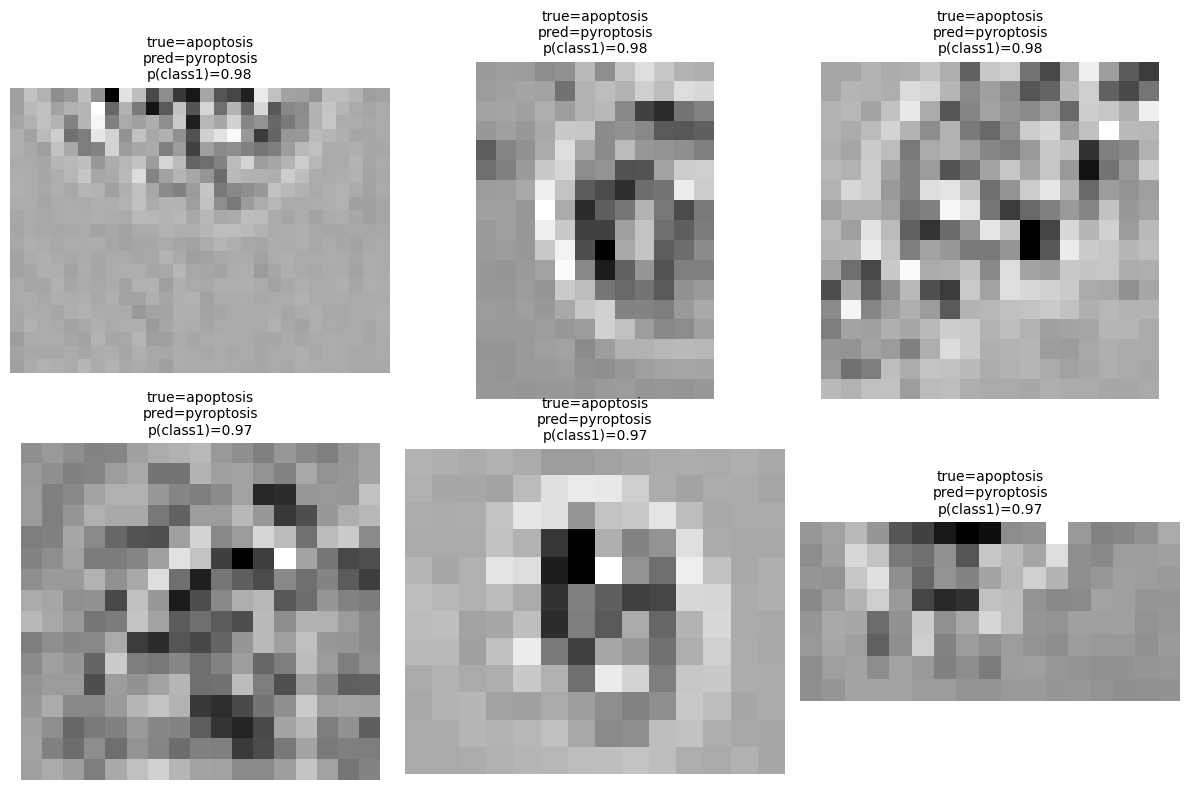

Artifacts written to: /media/capp/TMP2/DeathScope/training/ConvNeXt


In [13]:
best_checkpoint_path = RUN_DIR / "model_best.pth"
if not best_checkpoint_path.is_file():
    raise RuntimeError("Training did not produce a best checkpoint.")

best_checkpoint = load_checkpoint(best_checkpoint_path, device)
best_record = dict(best_checkpoint.get("metrics", best_record or {}))
best_model = build_model(ARCHITECTURE, num_classes=len(class_names), pretrained=False).to(device)
best_model.load_state_dict(best_checkpoint["model"])
best_model.eval()
best_val_metrics, best_targets, best_preds, best_probs, best_paths = evaluate(
    model=best_model,
    loader=val_loader,
    criterion=criterion,
    device=device,
)
best_record.setdefault("epoch", int(best_checkpoint["epoch"]))
best_record["val_loss"] = best_val_metrics.loss
best_record["val_acc"] = best_val_metrics.acc
best_record["val_f1"] = best_val_metrics.f1
best_record["val_auc"] = best_val_metrics.auc

conf_matrix = np.zeros((2, 2), dtype=np.int64)
for target, pred in zip(best_targets, best_preds):
    conf_matrix[int(target), int(pred)] += 1

final_metrics = {
    "best_epoch": int(best_record["epoch"]),
    "val_loss": float(best_record["val_loss"]),
    "val_acc": float(best_record["val_acc"]),
    "val_f1": float(best_record["val_f1"]),
    "val_auc": float(best_record["val_auc"]),
    "classes": idx_to_class,
    "confusion_matrix": conf_matrix.tolist(),
}
with (RUN_DIR / "final_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(final_metrics, file, indent=2)

display(pd.DataFrame([final_metrics]).drop(columns=["confusion_matrix", "classes"]))

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend(frameon=False)
axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend(frameon=False)
axes[2].plot(history_df["epoch"], history_df["train_f1"], label="train")
axes[2].plot(history_df["epoch"], history_df["val_f1"], label="val")
axes[2].set_title("F1")
axes[2].legend(frameon=False)
axes[3].plot(history_df["epoch"], history_df["val_auc"], label="val")
axes[3].set_title("Validation AUC")
axes[3].legend(frameon=False)
for ax in axes:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(conf_matrix, cmap="Blues")
ax.set_xticks([0, 1], [idx_to_class[0], idx_to_class[1]], rotation=20)
ax.set_yticks([0, 1], [idx_to_class[0], idx_to_class[1]])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Best Validation Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(conf_matrix[i, j]), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

best_samples = []
for path, target, pred, prob in zip(best_paths, best_targets, best_preds, best_probs):
    best_samples.append({
        "path": path,
        "target": int(target),
        "pred": int(pred),
        "prob_class_1": float(prob),
        "correct": bool(int(target) == int(pred)),
    })
preview_df = pd.DataFrame(best_samples).sort_values(["correct", "prob_class_1"], ascending=[True, False])
display(preview_df.head(10))

preview_rows = preview_df.head(6).to_dict(orient="records")
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for ax, row in zip(axes, preview_rows):
    image = cv2.imread(row["path"], cv2.IMREAD_GRAYSCALE)
    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"true={idx_to_class[row['target']]}\npred={idx_to_class[row['pred']]}\np(class1)={row['prob_class_1']:.2f}",
        fontsize=10,
    )
    ax.axis("off")
for ax in axes[len(preview_rows):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Artifacts written to: {RUN_DIR}")
